# Descriptive Analysis: WritingPrompts Story Generations

- WritingPrompts (Fan et al., 2018), test split
- 200 sampled prompts
- `seed=42`

**Models:**
- Gemma: google/gemma-2-9b-it
- Llama: meta-llama/Llama-3.1-8B-Instruct
- Mistral: mistralai/Mistral-7B-Instruct-v0.3
- Qwen: Qwen/Qwen2.5-7B-Instruct

**Decoding:** `temperature=1.0`, `top_p=0.9`, `repetition_penalty=1.0` (disabled), `n=5` samples per prompt (1000 stories per model)

**Reference:** all available human-written stories per prompt (`prompts_sample.jsonl`), each prompt filtered to have >=5 human references (`MIN_HUMAN_REFS=5`)

In [3]:
# Load libraries
import json
import re
import sys
import collections
import pathlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting parameters
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

# Locate the repo root regardless of the kernel's working directory, then pull in shared config
def find_repo_root(start=pathlib.Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data_generation' / 'generations' / 'storytelling_n200').is_dir():
            return p
    raise FileNotFoundError("Could not locate 'generations/storytelling_n200' above the current directory")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common import MODELS, MODEL_LABELS, MODEL_COLORS, MODEL_ORDER, GEN_ORDER

In [4]:
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / 'storytelling_n200'
FIG_DIR = REPO_ROOT / 'figures' / 'data_description'
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load & Prepare Data

In [5]:
# Generation configs (identical decoding params across models, saved per run)
configs = {key: json.load(open(DATA_DIR / f'config_{key}.json')) for key in MODELS}
config_overview = pd.DataFrame(configs).T[
    ['model_id', 'n_prompts', 'n_samples', 'temperature', 'top_p', 'repetition_penalty', 'max_new_tokens']
]

display(config_overview)

,model_id,n_prompts,n_samples,temperature,top_p,repetition_penalty,max_new_tokens
gemma,google/gemma-2-9b-it,200,5,1.0,0.9,1.0,1280
llama,meta-llama/Llama-3.1-8B-Instruct,200,5,1.0,0.9,1.0,1280
mistral,mistralai/Mistral-7B-Instruct-v0.3,200,5,1.0,0.9,1.0,1280
qwen,Qwen/Qwen2.5-7B-Instruct,200,5,1.0,0.9,1.0,1280


In [6]:
# Load generated stories (4 models x 200 prompts x 5 samples)
records = []
for key in MODELS:
    with open(DATA_DIR / f'writingprompts_{key}_n5.jsonl') as f:
        for line in f:
            r = json.loads(line)
            r['model_key'] = key
            records.append(r)

df_gen = pd.DataFrame(records)
df_gen['model'] = df_gen['model_key'].map(MODEL_LABELS)
df_gen['word_count'] = df_gen['story'].str.split().str.len()
df_gen['char_count'] = df_gen['story'].str.len()

print(f'Loaded {len(df_gen)} generated stories')
df_gen.head(3)

Loaded 4000 generated stories


,prompt_id,prompt,model,sample_idx,story,finish_reason,n_tokens,cjk_chars,language_ok,model_key,word_count,char_count
0,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,0,"The news came in a government broadcast, chill...",stop,520,0,True,gemma,391,2357
1,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,1,"The news hit like a supernova, exploding acros...",stop,580,0,True,gemma,433,2713
2,wp_0000,Turns out that the purpose of life is war. Hum...,Gemma-2-9B,2,"The message came on every screen, every phone,...",stop,585,0,True,gemma,442,2668


In [7]:
# Load human reference stories (all available references per prompt, >=5 per MIN_HUMAN_REFS)
human_records = [json.loads(l) for l in open(DATA_DIR / 'prompts_sample.jsonl')]
df_human = pd.DataFrame(human_records).explode('human_stories', ignore_index=True)
df_human['model_key'] = 'human'
df_human['model'] = 'Human'
df_human['story'] = df_human['human_stories']
df_human['word_count'] = df_human['story'].str.split().str.len()
df_human['char_count'] = df_human['story'].str.len()
df_human['prompt_word_count'] = df_human['prompt'].str.split().str.len()

refs_per_prompt = df_human.groupby('prompt_id').size()
print(f'Loaded {len(df_human)} human reference stories across {df_human.prompt_id.nunique()} prompts '
      f'(min={refs_per_prompt.min()}, mean={refs_per_prompt.mean():.1f}, max={refs_per_prompt.max()})')
df_human.head(3)

Loaded 1883 human reference stories across 200 prompts (min=5, mean=9.4, max=45)


,prompt,human_story,prompt_id,human_stories,model_key,model,story,word_count,char_count,prompt_word_count
0,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,"Here is my first post, I have always wanted to...",human,Human,"Here is my first post, I have always wanted to...",648,3553,45
1,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,`` The purpose of life is war. It has always b...,human,Human,`` The purpose of life is war. It has always b...,701,3907,45
2,Turns out that the purpose of life is war. Hum...,"Here is my first post, I have always wanted to...",wp_0000,"“ Dr. Garyson, you have five seconds to cut to...",human,Human,"“ Dr. Garyson, you have five seconds to cut to...",1059,5499,45


## Sanity Checks

In [8]:
# Every model should have exactly 5 samples for each of the 200 prompts
# All 5 sources (4 models + human) should refer to the same 200 prompts

samples_per_prompt = df_gen.groupby(['model_key', 'prompt_id']).size()
print(f'Generated stories: {len(df_gen)}  ({df_gen.model_key.nunique()} models x '
      f'{df_gen.prompt_id.nunique()} prompts x {samples_per_prompt.mean():.0f} samples)')

print(f'Samples per prompt (min / max): {samples_per_prompt.min()} / {samples_per_prompt.max()}')

human_refs_per_prompt = df_human.groupby('prompt_id').size()
print(f'Human reference stories: {len(df_human)} across {df_human.prompt_id.nunique()} prompts '
      f'(min / max per prompt: {human_refs_per_prompt.min()} / {human_refs_per_prompt.max()})')

prompt_id_sets = {key: frozenset(df_gen.loc[df_gen.model_key == key, 'prompt_id']) for key in MODELS}
prompt_id_sets['human'] = frozenset(df_human['prompt_id'])
print('All 5 sources share the same 200 prompt_ids:', len(set(prompt_id_sets.values())) == 1)

# Same prompt text across models (join key sanity check)
prompt_text = df_gen.drop_duplicates('prompt_id').set_index('prompt_id')['prompt']
human_prompt_text = df_human.drop_duplicates('prompt_id').set_index('prompt_id')['prompt']
print('Prompt text identical across generation + human files:',
      prompt_text.reindex(human_prompt_text.index).equals(human_prompt_text))

Generated stories: 4000  (4 models x 200 prompts x 5 samples)
Samples per prompt (min / max): 5 / 5
Human reference stories: 1883 across 200 prompts (min / max per prompt: 5 / 45)
All 5 sources share the same 200 prompt_ids: True
Prompt text identical across generation + human files: True


## Generation Quality Checks

In [9]:
# Truncation: finish_reason == 'length'
finish_tab = pd.crosstab(df_gen['model'], df_gen['finish_reason']).reindex(GEN_ORDER)
finish_tab['truncated_%'] = (finish_tab.get('length', 0) / finish_tab.sum(axis=1) * 100).round(1)
display(finish_tab)

finish_reason,length,stop,truncated_%
model,,,
Gemma-2-9B,0,1000,0.0
Llama-3.1-8B,4,996,0.4
Mistral-7B-v0.3,15,985,1.5
Qwen2.5-7B,3,997,0.3


In [10]:
# Language drift: non-Latin (CJK) script detected in an otherwise English story
CJK_RANGES = [(0x4E00, 0x9FFF), (0x3040, 0x30FF), (0xAC00, 0xD7AF)]  # CJK Unified, Hiragana/Katakana, Hangul
CJK = re.compile('[' + ''.join(chr(lo) + '-' + chr(hi) for lo, hi in CJK_RANGES) + ']')

# df_gen already carries cjk_chars/language_ok logged during generation; compute the same check for Human
df_human['cjk_chars'] = df_human['story'].apply(lambda s: len(CJK.findall(s)))
df_human['language_ok'] = df_human['cjk_chars'] == 0

df_lang = pd.concat([
    df_gen[['model', 'prompt_id', 'sample_idx', 'story', 'cjk_chars', 'language_ok']],
    df_human[['model', 'prompt_id', 'story', 'cjk_chars', 'language_ok']],
], ignore_index=True)

lang_tab = df_lang.groupby('model').agg(
    non_english=('language_ok', lambda s: int((~s).sum())),
    max_cjk_chars=('cjk_chars', 'max'),
).reindex(MODEL_ORDER)
lang_tab['non_english_%'] = (lang_tab['non_english'] / df_lang.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
display(lang_tab)

flagged = df_lang[~df_lang['language_ok']]
if len(flagged):
    print('\nFlagged stories:')
    for _, r in flagged.iterrows():
        share = r['cjk_chars'] / len(r['story'])
        ref = f"sample {int(r['sample_idx'])}" if pd.notna(r['sample_idx']) else 'reference'
        print(f"  {r['model']} / {r['prompt_id']} / {ref}: {share:.1%} CJK characters")

,non_english,max_cjk_chars,non_english_%
model,,,
Human,2,4,0.11
Gemma-2-9B,0,0,0.00
Llama-3.1-8B,0,0,0.00
Mistral-7B-v0.3,0,0,0.00
Qwen2.5-7B,6,1050,0.60



Flagged stories:
  Qwen2.5-7B / wp_0059 / sample 0: 0.1% CJK characters
  Qwen2.5-7B / wp_0127 / sample 0: 17.1% CJK characters
  Qwen2.5-7B / wp_0147 / sample 4: 18.7% CJK characters
  Qwen2.5-7B / wp_0177 / sample 3: 0.3% CJK characters
  Qwen2.5-7B / wp_0179 / sample 4: 0.1% CJK characters
  Qwen2.5-7B / wp_0190 / sample 2: 48.8% CJK characters
  Human / wp_0067 / reference: 0.1% CJK characters
  Human / wp_0082 / reference: 0.2% CJK characters


In [11]:
# Exact duplicates: identical story text sampled/referenced twice
df_dup_src = pd.concat([df_gen[['model', 'story']], df_human[['model', 'story']]], ignore_index=True)
dup_counts = df_dup_src.groupby('model')['story'].apply(lambda s: len(s) - s.nunique()).reindex(MODEL_ORDER)
dup_pct = (dup_counts / df_dup_src.groupby('model').size().reindex(MODEL_ORDER) * 100).round(2)
print('Exact duplicate stories per model:')
print(dup_counts)

Exact duplicate stories per model:
model
Human              1
Gemma-2-9B         0
Llama-3.1-8B       0
Mistral-7B-v0.3    0
Qwen2.5-7B         0
Name: story, dtype: int64


In [12]:
# Repeated openings: how concentrated are the first few words across all 1000 stories per model?
def top_opening_share(stories, n_words=4):
    openings = collections.Counter(' '.join(s.split()[:n_words]) for s in stories)
    opening, count = openings.most_common(1)[0]
    return count / len(stories), opening

quality_rows = []
for key in MODELS:
    sub = df_gen[df_gen.model_key == key]
    n = len(sub)
    share, opening = top_opening_share(sub['story'])
    quality_rows.append({
        'model': MODEL_LABELS[key],
        'truncated_%': (sub['finish_reason'] == 'length').mean() * 100,
        'non_english_%': (~sub['language_ok']).mean() * 100,
        'exact_dup_%': (n - sub['story'].nunique()) / n * 100,
        'top_opening_share_%': share * 100,
        'top_opening': opening,
    })

quality_df = pd.DataFrame(quality_rows).set_index('model').reindex(GEN_ORDER)
display(quality_df.round(2))

,truncated_%,non_english_%,exact_dup_%,top_opening_share_%,top_opening
model,,,,,
Gemma-2-9B,0.0,0.0,0.0,3.1,The air hung thick
Llama-3.1-8B,0.4,0.0,0.0,1.3,I stared at the
Mistral-7B-v0.3,1.5,0.0,0.0,30.4,In the heart of
Qwen2.5-7B,0.3,0.6,0.0,4.0,In the heart of


## Filtering Degenerate Generations

The exclusion rules live in **`common/data_prep.py`** (`load_texts`), so every downstream
notebook applies exactly the same filter:

- **LLM generations** — drop truncated stories (`finish_reason == 'length'`) and language drift
  (`language_ok == False`, i.e. CJK script in an English story).
- **Human references** — drop language drift (same CJK check) and exact-duplicate reference
  texts (first occurrence kept).

This cell only *applies* that decision to the raw frames above and prints the per-category
breakdown (`data_prep.exclusion_summary`). Human downsampling to 5 references per prompt happens
in the next section and, from there on, also replaces `df_human` for the rest of this notebook.

In [13]:
# Canonical filter from common/data_prep.py, applied to the raw frames loaded above.
# apply_human_cap=False -> this notebook describes the full cleaned reference corpus;
# the 5-per-prompt cap is documented separately in the next section.
from common import data_prep

_flags = data_prep.load_texts('storytelling_n200', apply_human_cap=False, with_dropped=True)

print('Excluded rows by source x reason (common/data_prep.py):')
print(data_prep.exclusion_summary('storytelling_n200', apply_human_cap=False).to_string(index=False))

# --- LLM generations: split raw df_gen into kept / excluded on (prompt_id, model_key, sample_idx) ---
_gen_drop = set(map(tuple, _flags.loc[_flags._drop & _flags.source.ne('human'),
                                      ['raw_prompt_id', 'source', 'story_id']].itertuples(index=False)))
_gen_mask = df_gen.set_index(['prompt_id', 'model_key', 'sample_idx']).index.isin(_gen_drop)
df_gen_excluded = df_gen[_gen_mask].copy()
df_gen = df_gen[~_gen_mask].reset_index(drop=True)

# --- Human references: story_id = position within the prompt's reference list (explode order) ---
df_human['story_id'] = df_human.groupby('prompt_id').cumcount()
_hum_drop = set(map(tuple, _flags.loc[_flags._drop & _flags.source.eq('human'),
                                      ['raw_prompt_id', 'story_id']].itertuples(index=False)))
_hum_mask = df_human.set_index(['prompt_id', 'story_id']).index.isin(_hum_drop)
df_human_excluded = df_human[_hum_mask].copy()
df_human = df_human[~_hum_mask].reset_index(drop=True)

print('\nRemaining generated stories per model:')
print(df_gen['model'].value_counts().reindex(GEN_ORDER))
print(f'\nRemaining human reference stories: {len(df_human)} across {df_human.prompt_id.nunique()} prompts '
      f'({len(df_human_excluded)} excluded)')

Excluded rows by source x reason (common/data_prep.py):
 source         _reason  n
  human exact_duplicate  1
  human  language_drift  2
  llama       truncated  4
mistral       truncated 15
   qwen  language_drift  5
   qwen       truncated  3

Remaining generated stories per model:
model
Gemma-2-9B         1000
Llama-3.1-8B        996
Mistral-7B-v0.3     985
Qwen2.5-7B          992
Name: count, dtype: int64

Remaining human reference stories: 1880 across 200 prompts (3 excluded)


## Human Reference Downsampling for the Diversity Metrics

The cleaned corpus above keeps every human story per prompt (5–45, mean 9.4). The
group-level diversity metrics instead use a fixed **5 human references per prompt**, drawn
per prompt with a fixed seed, so each human group matches the LLM group size (5 samples per
prompt) and the per-group diversity estimates are not confounded by group size. The draw and
the shared loader live in `common/data_prep.py` (`load_texts`, `to_groups`,
`selected_human_ids`).

This section first reports the cap's effect, then applies it: `df_human` is replaced by the
capped 5-per-prompt set for the remainder of this notebook (Length Distributions onward), so
those descriptive statistics match exactly what the metrics notebooks see. The full cleaned
corpus stays available as `df_human_full` for anything that predates the cap (e.g. the
exclusion examples below).

In [14]:
_cap = data_prep.HUMAN_CAP['storytelling_n200']
_sel = data_prep.selected_human_ids('storytelling_n200')
_per = pd.Series({p: len(v) for p, v in _sel.items()})

print(f'Seed: {data_prep.HUMAN_SAMPLE_SEED}   |   target: {_cap} references per prompt')
print(f'After the cap: {_per.sum()} human references across {len(_per)} prompts '
      f'(per prompt: min={_per.min()}, max={_per.max()})')
print(f'{(_per < _cap).sum()} prompt(s) below the cap — cleaning left fewer than {_cap} references there')

# Sanity: the capped human set is a subset of the cleaned corpus, positions preserved
_capped = data_prep.load_texts('storytelling_n200')
_capped_h = _capped[_capped.source.eq('human')]
_clean_pairs = set(map(tuple, df_human[['prompt_id', 'story_id']].itertuples(index=False)))
_cap_pairs = set(map(tuple, _capped_h[['raw_prompt_id', 'story_id']].itertuples(index=False)))
print(f'Capped set is a subset of the cleaned corpus: {_cap_pairs <= _clean_pairs}')

# Apply the cap: df_human becomes the 5-per-prompt set for the rest of this notebook, matching
# the metrics notebooks exactly. df_human_full keeps the pre-cap cleaned corpus for anything
# that still needs it (e.g. the exclusion examples further below).
df_human_full = df_human.copy()
df_human = df_human[
    df_human.set_index(['prompt_id', 'story_id']).index.isin(_cap_pairs)
].reset_index(drop=True)

print(f'\ndf_human replaced with the capped set: {len(df_human)} rows across '
      f'{df_human.prompt_id.nunique()} prompts (was {len(df_human_full)}).')

Seed: 20260902   |   target: 5 references per prompt
After the cap: 999 human references across 200 prompts (per prompt: min=4, max=5)
1 prompt(s) below the cap — cleaning left fewer than 5 references there
Capped set is a subset of the cleaned corpus: True

df_human replaced with the capped set: 999 rows across 200 prompts (was 1880).


## Length Distributions

In [15]:
df_all = pd.concat([
    df_gen[['prompt_id', 'model', 'word_count', 'char_count']],
    df_human[['prompt_id', 'model', 'word_count', 'char_count']],
], ignore_index=True)

length_summary = df_all.groupby('model')['word_count'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).reindex(MODEL_ORDER).round(1)
display(length_summary)

,count,mean,median,std,min,max
model,,,,,,
Human,999,539.1,452.0,364.1,100,1868
Gemma-2-9B,1000,474.3,475.0,70.6,137,760
Llama-3.1-8B,996,497.4,494.0,71.3,15,1108
Mistral-7B-v0.3,985,562.0,551.0,104.5,94,929
Qwen2.5-7B,992,546.5,542.0,118.5,16,972


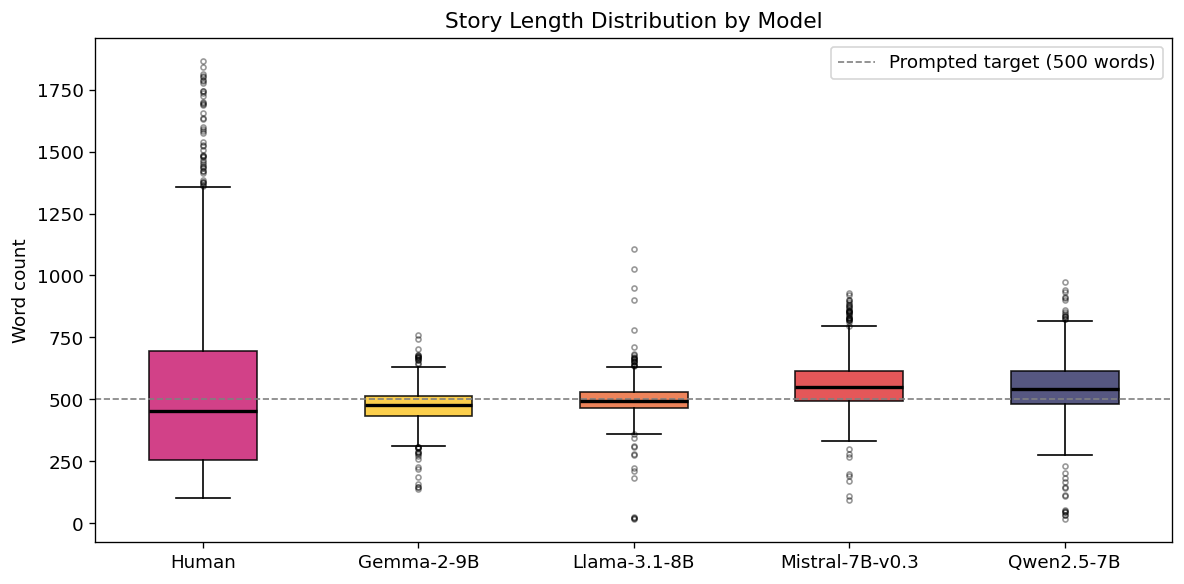

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
data = [df_all.loc[df_all.model == m, 'word_count'].values for m in MODEL_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=MODEL_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.axhline(500, color='gray', linestyle='--', linewidth=1, label='Prompted target (500 words)')
ax.set_ylabel('Word count')
ax.set_title('Story Length Distribution by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generated_length_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

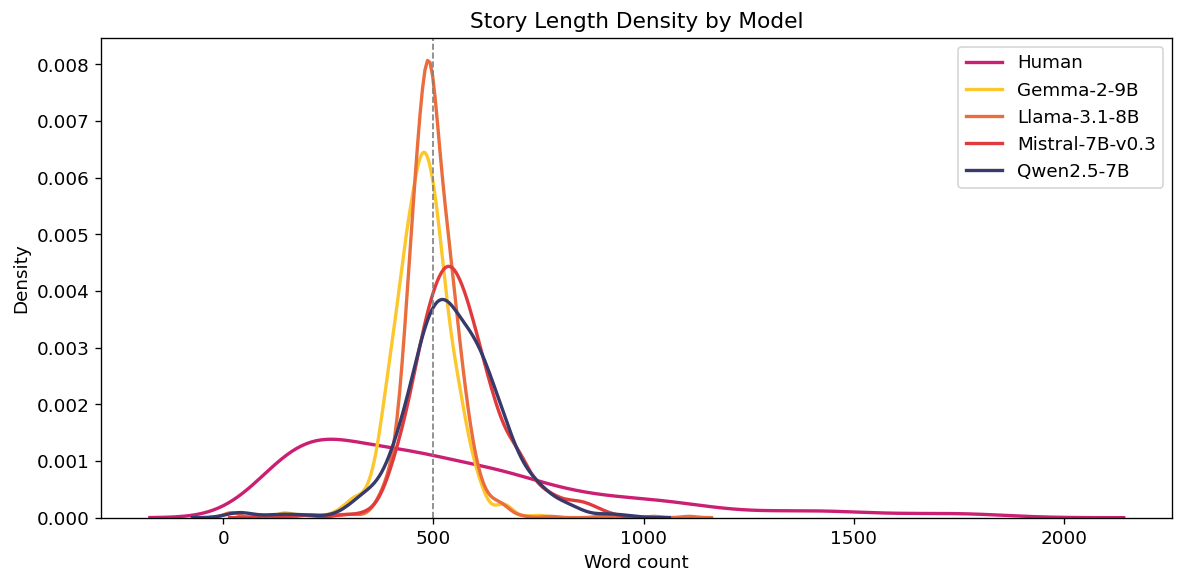

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for m in MODEL_ORDER:
    sns.kdeplot(df_all.loc[df_all.model == m, 'word_count'], label=m,
                color=MODEL_COLORS[m], linewidth=2, ax=ax)
ax.axvline(500, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Word count')
ax.set_title('Story Length Density by Model')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generated_length_kde.png', dpi=300, bbox_inches='tight')
plt.show()

## Within-Prompt Length Variability

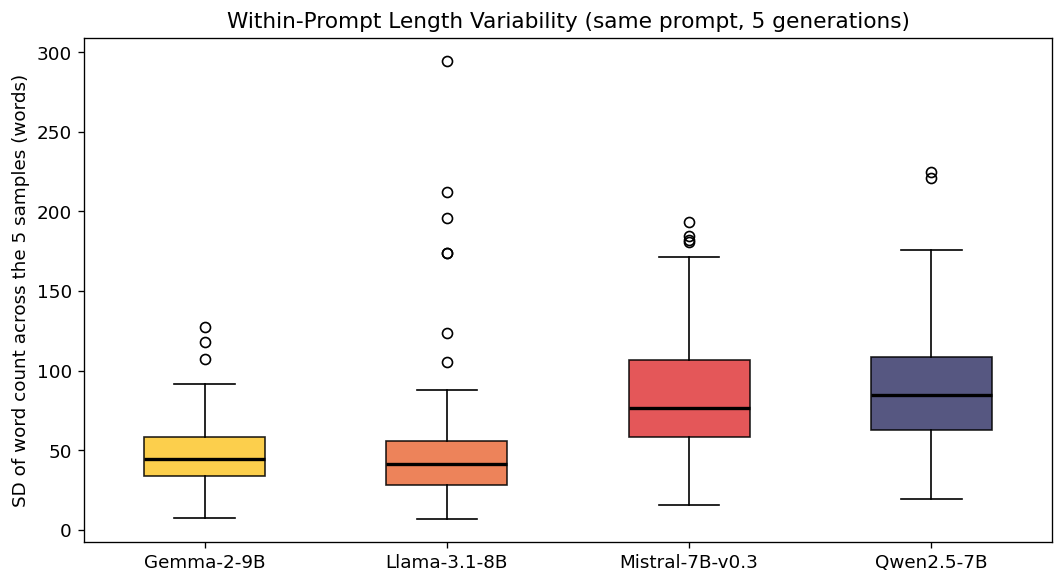

Mean within-prompt SD by model:
model
Gemma-2-9B         46.9
Llama-3.1-8B       47.2
Mistral-7B-v0.3    83.9
Qwen2.5-7B         87.3
Name: within_prompt_sd, dtype: float64


In [18]:
within_std = (df_gen.groupby(['model', 'prompt_id'])['word_count']
              .std().reset_index().rename(columns={'word_count': 'within_prompt_sd'}))

fig, ax = plt.subplots(figsize=(9, 5))
data = [within_std.loc[within_std.model == m, 'within_prompt_sd'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('SD of word count across the 5 samples (words)')
ax.set_title('Within-Prompt Length Variability (same prompt, 5 generations)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generated_within_prompt_variability.png', dpi=300, bbox_inches='tight')
plt.show()

print('Mean within-prompt SD by model:')
print(within_std.groupby('model')['within_prompt_sd'].mean().reindex(GEN_ORDER).round(1))

## Tokenizer Efficiency (tokens vs. words)

,mean,std
model,,
Gemma-2-9B,1.35,0.07
Llama-3.1-8B,1.27,0.05
Mistral-7B-v0.3,1.40,0.10
Qwen2.5-7B,1.27,0.10


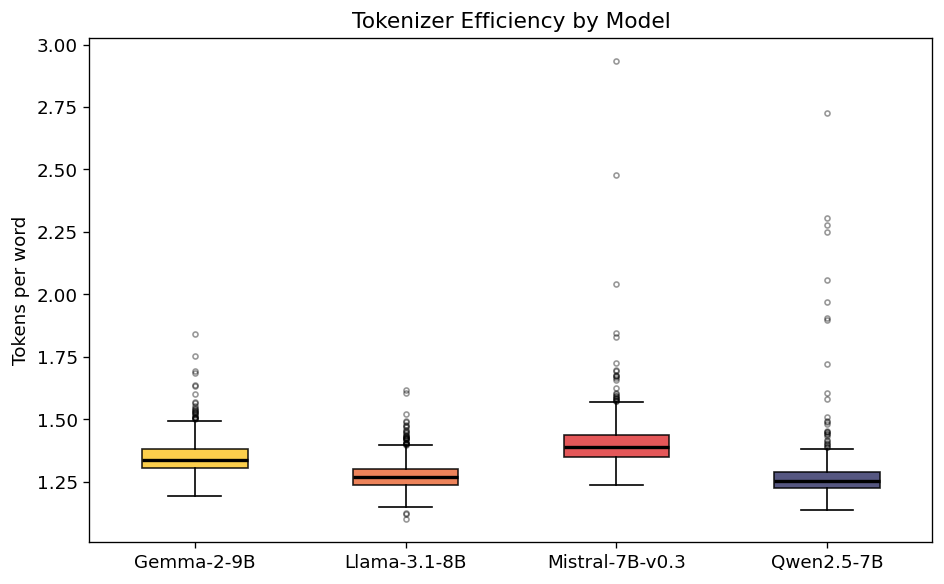

In [19]:
df_gen['tokens_per_word'] = df_gen['n_tokens'] / df_gen['word_count']
tok_summary = df_gen.groupby('model')['tokens_per_word'].agg(['mean', 'std']).reindex(GEN_ORDER).round(2)
display(tok_summary)

fig, ax = plt.subplots(figsize=(8, 5))
data = [df_gen.loc[df_gen.model == m, 'tokens_per_word'].values for m in GEN_ORDER]
bp = ax.boxplot(data, patch_artist=True, widths=0.5, tick_labels=GEN_ORDER,
                 medianprops=dict(color='black', linewidth=2),
                 flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, m in zip(bp['boxes'], GEN_ORDER):
    patch.set_facecolor(MODEL_COLORS[m])
    patch.set_alpha(0.85)

ax.set_ylabel('Tokens per word')
ax.set_title('Tokenizer Efficiency by Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generated_tokens_per_word.png', dpi=300, bbox_inches='tight')
plt.show()

## Prompt Length vs. Story Length

Pearson r(prompt length, story length) by model:
model
Gemma-2-9B         0.14
Llama-3.1-8B       0.04
Mistral-7B-v0.3    0.07
Qwen2.5-7B         0.14
dtype: float64


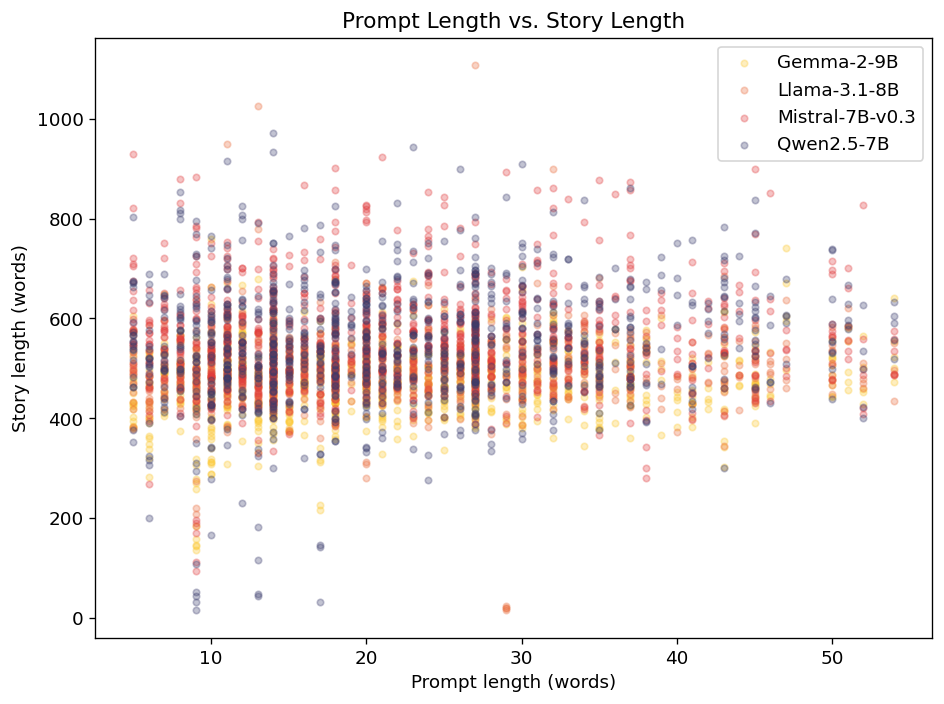

In [20]:
human_prompt_lengths = df_human[['prompt_id', 'prompt_word_count']].drop_duplicates('prompt_id')
merged = df_gen.merge(human_prompt_lengths, on='prompt_id')
corr_by_model = merged.groupby('model').apply(lambda g: g['prompt_word_count'].corr(g['word_count'])).reindex(GEN_ORDER)


print('Pearson r(prompt length, story length) by model:')
print(corr_by_model.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
for m in GEN_ORDER:
    sub = merged[merged.model == m]
    ax.scatter(sub['prompt_word_count'], sub['word_count'], alpha=0.3, s=15,
               color=MODEL_COLORS[m], label=m)
ax.set_xlabel('Prompt length (words)')
ax.set_ylabel('Story length (words)')
ax.set_title('Prompt Length vs. Story Length')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'storytelling_generated_prompt_vs_story_length.png', dpi=300, bbox_inches='tight')
plt.show()

## Qualitative Samples: Three Prompts Across All Models

In [21]:
example_ids = ['wp_0000', 'wp_0099', 'wp_0007']

for example_id in example_ids:
    n_human_refs = (df_human_full.prompt_id == example_id).sum()
    n_human_used = (df_human.prompt_id == example_id).sum()
    print(f'{"="*80}\nPROMPT_ID: {example_id}  '
          f'({n_human_refs} human references available, {n_human_used} used after the 5-cap; showing 1)')
    print('PROMPT:', df_human.loc[df_human.prompt_id == example_id, 'prompt'].iloc[0])
    print()

    for key, label in MODEL_LABELS.items():
        if key == 'human':
            story = df_human.loc[df_human.prompt_id == example_id, 'story'].iloc[0]
        else:
            story = df_gen.loc[(df_gen.model_key == key) & (df_gen.prompt_id == example_id)
                                & (df_gen.sample_idx == 0), 'story'].iloc[0]
        print(f'--- {label} ({len(story.split())} words) ---')
        print(story[:400] + ('...' if len(story) > 400 else ''))
        print()
    print()

PROMPT_ID: wp_0000  (6 human references available, 5 used after the 5-cap; showing 1)
PROMPT: Turns out that the purpose of life is war. Humans are self-multiplying shock troops, left to our own until our numbers get high enough to be useful in the ongoing galactic war. Today our previously thought to be useless DNA has been flipped to ON.

--- Gemma-2-9B (391 words) ---
The news came in a government broadcast, chilling and unavoidable. No time for dissent, no room for debate. We were not meant for this planet. Not truly. We were, in the words of the stoic, emotionless announcer, "galactic shock troops, dormant until activation." 

The activation, it turned out, wasn't some future event, some technological marvel. It was already here, a flip of a switch in our DNA...

--- Llama-3.1-8B (436 words) ---
The dreams. They'd started a few days ago, vague at first, but growing more intense with each passing night. I'd wake up to the feeling of something stirring, a low hum in the pit of my st

## Summary

In [22]:
summary = length_summary.copy()
summary['truncated_%'] = quality_df['truncated_%'].reindex(MODEL_ORDER)
summary['non_english_%'] = lang_tab['non_english_%']
summary['exact_dup_%'] = dup_pct

summary.to_csv(FIG_DIR / 'storytelling_generated_summary_stats.csv')
display(summary)

,count,mean,median,std,min,max,truncated_%,non_english_%,exact_dup_%
model,,,,,,,,,
Human,999,539.1,452.0,364.1,100,1868,NaN,0.11,0.05
Gemma-2-9B,1000,474.3,475.0,70.6,137,760,0.0,0.00,0.00
Llama-3.1-8B,996,497.4,494.0,71.3,15,1108,0.4,0.00,0.00
Mistral-7B-v0.3,985,562.0,551.0,104.5,94,929,1.5,0.00,0.00
Qwen2.5-7B,992,546.5,542.0,118.5,16,972,0.3,0.60,0.00


## Qualitative Examples: Exclusion Categories

One illustrative example per exclusion category (truncation, language drift, exact duplication), pulled directly from the rows filtered out above (`df_gen_excluded` / `df_human_excluded`) for reference in the thesis text.

In [23]:
print('=' * 80)
print('TRUNCATED EXAMPLE (finish_reason == "length")')
print('=' * 80)
row = df_gen_excluded[(df_gen_excluded.model == 'Llama-3.1-8B')
                       & (df_gen_excluded.prompt_id == 'wp_0194')
                       & (df_gen_excluded.sample_idx == 0)].iloc[0]
print(f"Model: {row['model']}  |  prompt_id: {row['prompt_id']}  |  sample_idx: {row['sample_idx']}  "
      f"|  finish_reason: {row['finish_reason']}")
print('Prompt:', row['prompt'])
print(f"\nStory length: {len(row['story'].split())} words, {len(row['story'])} chars")
print('\n--- Beginning ---')
print(row['story'][:250])
print('\n--- Cut off mid-clause at the token limit ---')
print('...' + row['story'][-300:])

print()
print('=' * 80)
print('DUPLICATE EXAMPLE (identical text submitted as two separate human references)')
print('=' * 80)
removed = df_human_excluded[df_human_excluded.prompt_id == 'wp_0111'].iloc[0]
kept = df_human_full[(df_human_full.prompt_id == 'wp_0111') & (df_human_full.story == removed['story'])].iloc[0]
print("prompt_id: wp_0111  |  kept as one reference, removed as an exact-duplicate second reference")
print('Texts identical:', kept['story'] == removed['story'])
print(f"\nStory ({len(kept['story'].split())} words):")
print(kept['story'][:400] + '...')

print()
print('=' * 80)
print('NON-ENGLISH / LANGUAGE DRIFT EXAMPLE (CJK script mid-story)')
print('=' * 80)
row = df_gen_excluded[(df_gen_excluded.model == 'Qwen2.5-7B')
                       & (df_gen_excluded.prompt_id == 'wp_0147')
                       & (df_gen_excluded.sample_idx == 4)].iloc[0]
cjk_share = row['cjk_chars'] / len(row['story'])
print(f"Model: {row['model']}  |  prompt_id: {row['prompt_id']}  |  sample_idx: {row['sample_idx']}  "
      f"|  finish_reason: {row['finish_reason']}  |  CJK share: {cjk_share:.1%}")
print('Prompt:', row['prompt'])
pos = CJK.search(row['story']).start()
print(f'\n--- Switch point (English -> Chinese), character offset {pos} ---')
print(row['story'][max(0, pos - 150):pos + 250])

TRUNCATED EXAMPLE (finish_reason == "length")
Model: Llama-3.1-8B  |  prompt_id: wp_0194  |  sample_idx: 0  |  finish_reason: length
Prompt: Write a story where each sentence has one more word than the last.

Story length: 1213 words, 6988 chars

--- Beginning ---
The house was.
The house was old.
The house was very old.
The house was very old now.
The house was very old now standing.
The house was very old now standing alone.
The house was very old now standing alone on.
The house was very old now standing al

--- Cut off mid-clause at the token limit ---
...to the night with a feeling of deep and foreboding that filled.
The house was very old now standing alone on the hill overlooking the town below through the dark mist swirling around it fiercely like a storm brewing slowly above them now approaching rapidly today darkening slowly into the night with

DUPLICATE EXAMPLE (identical text submitted as two separate human references)
prompt_id: wp_0111  |  kept as one reference, removed 